In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tsa_evaluation_results.json
/kaggle/input/gcv-ocr.csv
/kaggle/input/vsa_expt_results.json
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral6.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral12.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral7.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral15.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral2.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral11.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral8.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral14.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral1.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral10.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral4.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral13.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral5.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral3.jpg
/kaggle/input/dataset/

In [ ]:
# Install necessary packages
!pip install -q --upgrade pip
!pip install -q ftfy regex tqdm torch torchvision timm

# Exit any current Jupyter execution (optional if needed)
import os
import sys
os._exit(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.1 MB/s eta 0:00:00


In [2]:
# ======================= #
#     STEP 1: IMPORTS     #
# ======================= #

# Imports
import os
import pandas as pd
import torch
import timm  # for Xception model
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

In [3]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, preprocess, label_encoder):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.label_encoder = label_encoder
        self.data['sentiment'] = self.label_encoder.fit_transform(
            self.data['sentiment'].str.lower().str.strip()
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert("RGB")
        image = self.preprocess(image)
        label = row['sentiment']
        return image, label


In [4]:
import torchvision.transforms as transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ViT-L/16 input
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],        # Can also use [0.485, 0.456, 0.406]
        std=[0.5, 0.5, 0.5]          # or [0.229, 0.224, 0.225] for ImageNet
    )
])


In [5]:
# os.listdir("/kaggle/input/basket")
import os

temp_data = pd.DataFrame(columns=["filename","label"])
all_files = os.listdir("/kaggle/input/dataset/basket")
all_files.sort()

In [6]:
import os

temp_data = pd.DataFrame(columns=["filename","sentiment"])
all_files = os.listdir("/kaggle/input/dataset/basket")
all_files.sort()

for file in all_files:
    label = file.split("_")[0]
    # print(label)
    # print(file)
    temp_data = pd.concat([temp_data, pd.DataFrame([[file, label]], columns=["filename", "sentiment"])], ignore_index=True)
    # print(temp_data)
    # break

# Optional: Display the DataFrame
print(temp_data.head())

           filename sentiment
0  negative_001.jpg  negative
1  negative_002.jpg  negative
2  negative_003.jpg  negative
3  negative_004.jpg  negative
4  negative_005.jpg  negative


In [7]:
temp_data.to_csv("temp_data.csv", index=False)

In [8]:
import timm
import torchvision.transforms as transforms
import torch
import torch.nn as nn

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 3

# Load Xception model from timm
xception_model = timm.create_model("xception", pretrained=True)
in_features = xception_model.get_classifier().in_features
xception_model.reset_classifier(num_classes)  # Replace head for classification
xception_model = xception_model.to(device)

# Preprocessing (matching Xception's ImageNet expectations)
preprocess = transforms.Compose([
    transforms.Resize((299, 299)),  # Xception default input size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [9]:
temp_data

,filename,sentiment
0,negative_001.jpg,negative
1,negative_002.jpg,negative
2,negative_003.jpg,negative
3,negative_004.jpg,negative
4,negative_005.jpg,negative
...,...,...
2870,positive_995.jpg,positive
2871,positive_996.jpg,positive
2872,positive_997.jpg,positive
2873,positive_998.jpg,positive


In [10]:
# Freeze Xception parameters (like you did with CLIP)
for param in xception_model.parameters():
    param.requires_grad = False

# But unfreeze the classification head so it can learn
for param in xception_model.get_classifier().parameters():
    param.requires_grad = True

# Label encoder
le = LabelEncoder()

# Dataset
csv_path = "/kaggle/working/temp_data.csv"
img_dir = "/kaggle/input/dataset/basket"
dataset = CustomImageDataset(csv_path, img_dir, preprocess, le)

# Split into train, val, test
from torch.utils.data import random_split
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)


In [11]:
# Get one batch from the dataloader
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([16, 3, 299, 299])
Labels shape: torch.Size([16])
Labels: tensor([1, 1, 2, 0, 2, 2, 0, 2, 2, 1, 1, 0, 1, 2, 2, 0])


In [12]:
# Image encoder is the full Xception model (already frozen except head)
image_encoder = xception_model

# Define classifier for Xception
# class XceptionClassifier(nn.Module):
class XceptionClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        with torch.no_grad():
            features = self.encoder.forward_features(image)   # [B, 2048, H, W]
            pooled = self.encoder.forward_head(features, pre_logits=True)  # [B, 2048]
        pooled = pooled.float()
        return self.classifier(pooled)  # [B, num_classes]

# Xception has 2048-dimensional pre-logits
model = XceptionClassifier(image_encoder, embed_dim=2048, num_classes=3).to(device)



In [13]:
# !pip install -q ipywidgets

In [14]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Early stopping and tracking setup
best_val_loss = float('inf')
patience = 0
counter = 0
train_losses = []
val_losses = []

# Loss and optimizer (Xception classifier layer only)
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

# 1. Define optimizer with different LRs for classifier and encoder
optimizer = optim.AdamW([
    {"params": model.classifier.parameters(), "lr": 1e-4},  # classifier: faster learning
    {"params": [p for p in model.encoder.parameters() if p.requires_grad], "lr": 1e-5}  # encoder: slower learning
], weight_decay=1e-4)

# 2. Define LR scheduler (Cosine Annealing here)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training loop
for epoch in range(250):  # Can increase for better results
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_xception_model.pt")
        print("✅ Model saved.")
        counter = 0
    # else:
    #     counter += 1
    #     print(f"⚠️ Early stopping warning ({counter}/{patience}")
    #     if counter >= patience:
    #         print("⛔ Early stopping triggered.")
    #         break


Epoch 1 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1, Train Loss: 1.0358, Val Loss: 0.9680
✅ Model saved.


Epoch 2 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

...

Epoch 249 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 249, Train Loss: 0.4001, Val Loss: 0.4817


Epoch 250 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 250 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 250, Train Loss: 0.4059, Val Loss: 0.4809


In [15]:
best_val_loss

0.47217558324337006

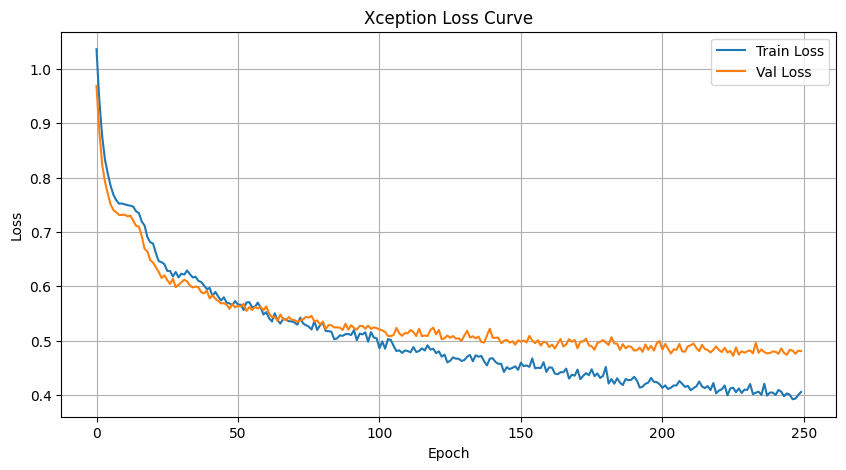

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Xception Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig("Xception__loss_curve.png")
plt.show()


In [17]:
import json
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import torch

# Load best model
model.load_state_dict(torch.load("best_xception_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Decode labels
class_names = list(le.classes_)

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# Classification Report as dictionary
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

print(report_dict)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Final JSON metrics
metrics = {
    "model_name": "Xception",
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict
}

# Save JSON
with open("test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Metrics saved to test_metrics.json")


Inference: 100%|██████████| 18/18 [00:05<00:00,  3.20it/s]

🎯 Test Accuracy: 78.82%
{'negative': {'precision': 0.8941176470588236, 'recall': 0.8, 'f1-score': 0.8444444444444443, 'support': 95}, 'neutral': {'precision': 0.6574074074074074, 'recall': 0.797752808988764, 'f1-score': 0.7208121827411168, 'support': 89}, 'positive': {'precision': 0.8421052631578947, 'recall': 0.7692307692307693, 'f1-score': 0.8040201005025126, 'support': 104}, 'accuracy': 0.7881944444444444, 'macro avg': {'precision': 0.7978767725413752, 'recall': 0.7889945260731778, 'f1-score': 0.7897589092293579, 'support': 288}, 'weighted avg': {'precision': 0.802185357980099, 'recall': 0.7881944444444444, 'f1-score': 0.7916409615918157, 'support': 288}}
✅ Metrics saved to test_metrics.json


In [18]:
# 100 epochs, 3 patience, stopped at 47th epoch: 75.69% accuracy
# 100 epochs full: 79.86% accuracy
# 250 epochs, full: 78.82% accuracy, best model at 226th epoch